# Báo cáo các run Role-Aware Puppeteer trên GSM-Hard

Notebook này đọc trực tiếp artefact trong `puppeteer/runs` và `puppeteer/logs`, sau đó tổng hợp các biểu đồ gần với Dang et al. (2025): task performance, token/agent evolution, performance–cost, graph compaction và cyclicality.

Phạm vi hiện tại chỉ gồm các run Role-Aware đã hoàn thành; chưa thực hiện so sánh với phương pháp đối chứng. Các run có số sample khác nhau được trình bày riêng, không gộp thành một phép so sánh paired.

Quy ước quan trọng:
- Nhãn experiment lấy từ registry bên dưới thay vì suy ra từ timestamp, vì folder đã được đổi tên thủ công sau khi chạy.
- `total_tokens` là tổng token của mọi reasoning path trong một task; `agent_activations` là tổng số lần agent được kích hoạt.
- `edge_node_ratio = E/N_active` là proxy compaction có thể lớn hơn 1; cyclicality được tính trực tiếp từ directed agent graph.

In [1]:
from __future__ import annotations

import ast
import json
import math
import re
import warnings
from collections import Counter
from concurrent.futures import ThreadPoolExecutor
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 180, "axes.titleweight": "bold"})

def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "puppeteer" / "runs").is_dir():
            return candidate
    raise FileNotFoundError("Không tìm thấy project root chứa puppeteer/runs")

PROJECT_ROOT = find_project_root()
PUPPETEER_ROOT = PROJECT_ROOT / "puppeteer"
RUNS_ROOT = PUPPETEER_ROOT / "runs"
LOGS_ROOT = PUPPETEER_ROOT / "logs"
DATASET_PATH = PUPPETEER_ROOT / "data" / "GSM-Hard" / "test.parquet"
REPORT_DIR = PROJECT_ROOT / "output" / "gsm_hard_role_aware_report"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Project: {PROJECT_ROOT}")
print(f"Report output: {REPORT_DIR}")

Project: D:\SideProject\ChatDev
Report output: D:\SideProject\ChatDev\output\gsm_hard_role_aware_report


In [2]:
# Đây là nơi duy nhất cần sửa nếu bạn đổi tên folder hoặc thêm run mới.
EXPERIMENTS = [
    {
        "key": "evolved_s0_subset",
        "label": "Evolved S0 (225-sample subset)",
        "role": "evaluation",
        "run_folders": ["gsm-hard_train_seed42_20260824_trained_final"],
        "log_group": "GSM-Hard-24-08-evolved",
        "color": "#3366CC",
        "manual_mode": "evolved",
        "include_topology": False,
    },
    {
        "key": "evolved_s3_small",
        "label": "Evolved S3-small",
        "role": "evaluation",
        "run_folders": [
            "gsm-hard_train_seed42_20260825_094700",
            "gsm-hard_train_seed42_20260825_s3_small_1",
            "gsm-hard_train_seed42_20260825_s3_small_2",
            "gsm-hard_train_seed42_20260825_s3_small_3",
        ],
        "log_group": "GSM-Hard24-08-s3-small",
        "color": "#E8710A",
        "manual_mode": "evolved",
    },
    {
        "key": "evolved_s0_full",
        "label": "Evolved S0 (full final)",
        "role": "full_evaluation",
        "run_folders": ["gsm-hard_train_seed42_20260822_evolved"],
        "log_group": "GSM-Hard-22-08",
        "log_start": "2026-08-22T15:48:27",
        "color": "#109618",
        "manual_mode": "evolved",
        "parse_logs": False,
    },
    {
        "key": "training_s0",
        "label": "S0 training run",
        "role": "training",
        "run_folders": ["gsm-hard_train_seed42_20260823_train"],
        "log_group": "GSM-Hard-23-08-train",
        "color": "#7B1FA2",
        "manual_mode": "train",
    },
]

EVALUATION_KEYS = ["evolved_s0_subset", "evolved_s3_small", "evolved_s0_full"]
EFFICIENCY_KEYS = ["evolved_s0_subset", "evolved_s3_small"]
TRAINING_KEY = "training_s0"

for spec in EXPERIMENTS:
    missing = [name for name in spec["run_folders"] if not (RUNS_ROOT / name).is_dir()]
    if missing:
        print(f"WARNING {spec['key']}: missing run folders: {missing}")
    if spec.get("parse_logs", True) and not (LOGS_ROOT / spec["log_group"]).is_dir():
        print(f"WARNING {spec['key']}: missing log group: {spec['log_group']}")

## Parser và định nghĩa metric

Log folder không chứa run ID trực tiếp, nên notebook nối log với result bằng `original_index` khôi phục từ nội dung câu hỏi GSM-Hard. Nếu cùng một item có nhiều log do retry/resume, bản ghi timestamp mới nhất được giữ và số duplicate được báo cáo. Graph được đọc từ dữ liệu `vis.DataSet` nhúng trong `agent_graph.html`; path metrics được đọc từ các file `path_*.jsonl` (thực tế là JSON array).


In [3]:
TIMESTAMP_FORMAT = "%Y-%m-%d-%H-%M-%S"
TASK_BLOCK_RE = re.compile(r"Task:\s*\r?\n(.*?)(?=\r?\n\[\d{4}-\d{2}-\d{2}\s)", re.DOTALL)
RAW_TASK_RE = re.compile(r"'task': (\{.*?\}), 'workflow':", re.DOTALL)
FINAL_ANSWER_RE = re.compile(r"\[Final Answer\]:\s*(.*)")
STEP_PENALTY_PER_ACTIVATION = 0.1
VIS_RE_TEMPLATE = r"{name}\s*=\s*new vis\.DataSet\((\[.*?\])\);"

def normalize_text(value) -> str:
    return re.sub(r"\s+", " ", str(value or "")).strip()

def parse_folder_timestamp(name: str):
    try:
        return datetime.strptime(name, TIMESTAMP_FORMAT)
    except ValueError:
        return pd.NaT

def read_jsonl(path: Path) -> list[dict]:
    if not path.is_file():
        return []
    rows = []
    for line in path.read_text(encoding="utf-8", errors="replace").splitlines():
        if line.strip():
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                pass
    return rows

def read_path_actions(path: Path) -> list[dict]:
    try:
        payload = json.loads(path.read_text(encoding="utf-8", errors="replace"))
        if isinstance(payload, list):
            return [row for row in payload if isinstance(row, dict)]
        if isinstance(payload, dict):
            return [payload]
    except (OSError, json.JSONDecodeError):
        return read_jsonl(path)
    return []

def parse_vis_dataset(html_path: Path, name: str) -> list[dict]:
    if not html_path.is_file():
        return []
    text = html_path.read_text(encoding="utf-8", errors="replace")
    match = re.search(VIS_RE_TEMPLATE.format(name=re.escape(name)), text, re.DOTALL)
    if not match:
        return []
    try:
        value = json.loads(match.group(1))
        return value if isinstance(value, list) else []
    except json.JSONDecodeError:
        return []

def graph_metrics(log_dir: Path) -> dict:
    nodes = parse_vis_dataset(log_dir / "agent_graph.html", "nodes")
    edges = parse_vis_dataset(log_dir / "agent_graph.html", "edges")
    edge_pairs = [(edge.get("from"), edge.get("to")) for edge in edges if edge.get("from") is not None and edge.get("to") is not None]
    active_nodes = set(value for pair in edge_pairs for value in pair)
    graph = nx.DiGraph()
    graph.add_nodes_from(active_nodes)
    graph.add_edges_from(edge_pairs)
    simple_no_loops = nx.DiGraph((u, v) for u, v in graph.edges() if u != v)
    simple_no_loops.add_nodes_from(graph.nodes())
    density = nx.density(simple_no_loops) if simple_no_loops.number_of_nodes() > 1 else 0.0
    try:
        cycles = list(nx.simple_cycles(graph, length_bound=4))
    except TypeError:
        cycles = [cycle for cycle in nx.simple_cycles(graph) if len(cycle) <= 4]
    cycle_counts = Counter(len(cycle) for cycle in cycles)
    return {
        "graph_pool_nodes": len(nodes),
        "graph_active_nodes": len(active_nodes),
        "graph_edges": len(edge_pairs),
        "graph_unique_edges": graph.number_of_edges(),
        "edge_node_ratio": len(edge_pairs) / max(len(active_nodes), 1),
        "directed_density": density,
        **{f"cycles_len_{length}": cycle_counts.get(length, 0) for length in range(1, 5)},
    }

def extract_task_identity(log_dir: Path, meta_text: str, question_lookup: dict[str, int]):
    match = TASK_BLOCK_RE.search(meta_text)
    question = match.group(1).strip() if match else None
    original_index = question_lookup.get(normalize_text(question)) if question else None
    if original_index is not None:
        return int(original_index), question
    fallback_text = meta_text
    for path in sorted(log_dir.glob("path*.log")):
        fallback_text += "\n" + path.read_text(encoding="utf-8", errors="replace")
    for raw in reversed(RAW_TASK_RE.findall(fallback_text)):
        try:
            task = ast.literal_eval(raw)
        except (SyntaxError, ValueError):
            continue
        if isinstance(task, dict):
            return task.get("original_index", task.get("id")), task.get("Question", question)
    return None, question

def parse_task_header(meta_path: Path, question_lookup: dict[str, int]) -> dict:
    if not meta_path.is_file():
        return {"original_index": None, "question": None}
    question_lines = []
    in_task = False
    timestamp_line = re.compile(r"^\[\d{4}-\d{2}-\d{2}\s")
    with meta_path.open("r", encoding="utf-8", errors="replace") as source:
        for line in source:
            stripped = line.rstrip("\r\n")
            if stripped == "Task:":
                in_task = True
                question_lines = []
                continue
            if in_task:
                if timestamp_line.match(stripped):
                    break
                question_lines.append(stripped)
    question = "\n".join(question_lines).strip() or None
    original_index = question_lookup.get(normalize_text(question)) if question else None
    return {"original_index": original_index, "question": question}

def parse_log_folder(log_dir: Path, question_lookup: dict[str, int], include_topology: bool = False) -> dict:
    meta_path = log_dir / "meta.log"
    task_header = parse_task_header(meta_path, question_lookup)
    original_index = task_header["original_index"]
    question = task_header["question"]
    reward_rows = read_jsonl(log_dir / "trajectory_rewards.jsonl")
    reward_tokens = sum(float(row.get("total_tokens", 0) or 0) for row in reward_rows)
    reward_cost = sum(float(row.get("total_cost", 0) or 0) for row in reward_rows)
    path_lengths = [
        max(0, int(round(float(row.get("step_penalty", 0) or 0) / STEP_PENALTY_PER_ACTIVATION)))
        for row in reward_rows
    ]
    path_lengths = [length for length in path_lengths if length > 0]
    role_counts = Counter()
    agent_activations = sum(path_lengths)
    step_tokens = reward_tokens
    step_cost = reward_cost
    total_tokens = reward_tokens
    total_cost = reward_cost
    return {
        "log_folder": str(log_dir),
        "log_folder_name": log_dir.name,
        "run_timestamp": parse_folder_timestamp(log_dir.name),
        "original_index": int(original_index) if original_index is not None else np.nan,
        "question": question,
        "final_answer_from_log": None,
        "path_count": len(path_lengths),
        "agent_activations": agent_activations,
        "unique_roles": np.nan,
        "mean_chain_length": float(np.mean(path_lengths)) if path_lengths else np.nan,
        "max_chain_length": max(path_lengths, default=np.nan),
        "total_tokens": total_tokens,
        "total_cost": total_cost,
        "reward_total_tokens": reward_tokens,
        "reward_total_cost": reward_cost,
        "token_trace_delta": step_tokens - reward_tokens if reward_rows and agent_activations else np.nan,
        "role_counts": dict(role_counts),
        "parse_ok": original_index is not None and bool(reward_rows),
        **(graph_metrics(log_dir) if include_topology else {
            "graph_pool_nodes": np.nan, "graph_active_nodes": np.nan, "graph_edges": np.nan,
            "graph_unique_edges": np.nan, "edge_node_ratio": np.nan, "directed_density": np.nan,
            **{f"cycles_len_{length}": np.nan for length in range(1, 5)},
        }),
    }

def lowess_numpy(x, y, frac=0.25, grid=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    if len(x) < 3:
        return x, y
    order = np.argsort(x)
    x, y = x[order], y[order]
    grid = np.asarray(grid if grid is not None else x, dtype=float)
    neighbors = max(3, min(len(x), int(math.ceil(frac * len(x)))))
    fitted = []
    for x0 in grid:
        distance = np.abs(x - x0)
        bandwidth = np.partition(distance, neighbors - 1)[neighbors - 1]
        if bandwidth <= 0:
            fitted.append(float(np.mean(y[distance == 0])))
            continue
        u = np.clip(distance / bandwidth, 0, 1)
        weight = (1 - u ** 3) ** 3
        design = np.column_stack([np.ones_like(x), x - x0])
        root_w = np.sqrt(weight)[:, None]
        beta, *_ = np.linalg.lstsq(design * root_w, y * root_w.ravel(), rcond=None)
        fitted.append(float(beta[0]))
    return grid, np.asarray(fitted)

def wilson_interval(successes: int, total: int, z=1.959963984540054):
    if total <= 0:
        return np.nan, np.nan
    p = successes / total
    denom = 1 + z * z / total
    center = (p + z * z / (2 * total)) / denom
    half = z * math.sqrt(p * (1 - p) / total + z * z / (4 * total * total)) / denom
    return center - half, center + half

def save_figure(fig, name: str):
    path = REPORT_DIR / name
    fig.savefig(path, bbox_inches="tight")
    print(f"Saved: {path.name}")
    return path


In [4]:
dataset = pd.read_parquet(DATASET_PATH).reset_index().rename(columns={"index": "original_index"})
question_lookup = {
    normalize_text("Solve this math problem and return the final numerical answer:\n" + row.input): int(row.original_index)
    for row in dataset[["original_index", "input"]].itertuples(index=False)
}

def run_metadata(run_folder: str) -> dict:
    config_path = RUNS_ROOT / run_folder / "resolved_config.yaml"
    config = yaml.safe_load(config_path.read_text(encoding="utf-8")) if config_path.is_file() else {}
    policy = config.get("policy", {}) or {}
    dataset_cfg = config.get("dataset", {}) or {}
    return {
        "run_folder": run_folder,
        "internal_run_id": config.get("run_id"),
        "config_policy_type": policy.get("type"),
        "config_policy_mode": policy.get("policy_mode"),
        "config_dataset_mode": dataset_cfg.get("mode"),
        "data_start": dataset_cfg.get("data_start"),
        "data_limit": dataset_cfg.get("data_limit"),
        "personas_path": config.get("personas_path"),
    }

def load_results(spec: dict) -> pd.DataFrame:
    frames = []
    for rank, run_folder in enumerate(spec["run_folders"]):
        result_dir = RUNS_ROOT / run_folder / "results"
        for path in sorted(result_dir.glob("*.jsonl")):
            if "uncommitted_after" in path.name or path.stat().st_size == 0:
                continue
            rows = read_jsonl(path)
            if not rows:
                continue
            frame = pd.DataFrame(rows)
            frame["source_result"] = str(path)
            frame["source_run_folder"] = run_folder
            frame["run_rank"] = rank
            frames.append(frame)
    if not frames:
        return pd.DataFrame()
    result = pd.concat(frames, ignore_index=True)
    if "original_index" not in result:
        result["original_index"] = result.get("id")
    result["original_index"] = pd.to_numeric(result["original_index"], errors="coerce")
    result = result.dropna(subset=["original_index"]).copy()
    result["original_index"] = result["original_index"].astype(int)
    result = result.sort_values(["run_rank", "batch_index"] if "batch_index" in result else ["run_rank"])
    return result.drop_duplicates("original_index", keep="last")

def load_logs(spec: dict) -> tuple[pd.DataFrame, int]:
    if not spec.get("parse_logs", True):
        return pd.DataFrame(), 0
    group = LOGS_ROOT / spec["log_group"]
    folders = sorted((path for path in group.iterdir() if path.is_dir()), key=lambda path: path.name) if group.is_dir() else []
    if spec.get("log_start"):
        lower = pd.Timestamp(spec["log_start"])
        folders = [path for path in folders if pd.notna(parse_folder_timestamp(path.name)) and parse_folder_timestamp(path.name) >= lower]
    if spec.get("log_end"):
        upper = pd.Timestamp(spec["log_end"])
        folders = [path for path in folders if parse_folder_timestamp(path.name) < upper]
    include_topology = spec.get("include_topology", False)
    def parse_one(path):
        return parse_log_folder(path, question_lookup, include_topology=include_topology)
    workers = min(8, max(1, len(folders)))
    with ThreadPoolExecutor(max_workers=workers) as pool:
        rows = list(pool.map(parse_one, folders))
    print("{}: parsed {}/{} log folders".format(spec["key"], len(rows), len(folders)), flush=True)
    logs = pd.DataFrame(rows)
    if logs.empty:
        return logs, 0
    logs = logs.dropna(subset=["original_index"]).copy()
    logs["original_index"] = logs["original_index"].astype(int)
    duplicate_count = int(logs.duplicated("original_index", keep=False).sum())
    logs = logs.sort_values("run_timestamp").drop_duplicates("original_index", keep="last")
    return logs, duplicate_count

data_by_key = {}
inventory_rows = []
for spec in EXPERIMENTS:
    results = load_results(spec)
    logs, duplicate_logs = load_logs(spec)
    if results.empty:
        joined = results
    elif logs.empty:
        joined = results.copy()
    else:
        joined = results.merge(logs, on="original_index", how="left", validate="one_to_one", suffixes=("_result", "_log"))
    joined["experiment_key"] = spec["key"]
    joined["experiment_label"] = spec["label"]
    data_by_key[spec["key"]] = joined
    inventory_rows.append({
        "key": spec["key"],
        "label": spec["label"],
        "role": spec["role"],
        "result_rows": len(results),
        "parsed_unique_logs": len(logs),
        "joined_with_metrics": int(joined["total_tokens"].notna().sum()) if "total_tokens" in joined else 0,
        "duplicate_log_rows_before_dedup": duplicate_logs,
        "accuracy": float(joined["correct"].mean()) if "correct" in joined and len(joined) else np.nan,
    })

inventory = pd.DataFrame(inventory_rows)
display(inventory)


evolved_s0_subset: parsed 226/226 log folders


evolved_s3_small: parsed 230/230 log folders


training_s0: parsed 202/202 log folders


,key,label,role,result_rows,parsed_unique_logs,joined_with_metrics,duplicate_log_rows_before_dedup,accuracy
0,evolved_s0_subset,Evolved S0 (225-sample subset),evaluation,225,226,225,0,0.466667
1,evolved_s3_small,Evolved S3-small,evaluation,226,226,226,8,0.530973
2,evolved_s0_full,Evolved S0 (full final),full_evaluation,909,0,0,0,0.616062
3,training_s0,S0 training run,training,200,200,200,4,0.465000


In [5]:
mapping_rows = []
for spec in EXPERIMENTS:
    for folder in spec["run_folders"]:
        meta = run_metadata(folder)
        meta.update({
            "experiment_key": spec["key"],
            "manual_mode": spec["manual_mode"],
            "log_group": spec["log_group"],
            "mode_mismatch": spec["manual_mode"] != meta.get("config_policy_mode"),
        })
        mapping_rows.append(meta)
mapping = pd.DataFrame(mapping_rows)
display(mapping[["experiment_key", "run_folder", "internal_run_id", "manual_mode", "config_policy_mode", "mode_mismatch", "personas_path", "log_group"]])

if mapping["mode_mismatch"].any():
    print("CẢNH BÁO: Có mismatch giữa nhãn thủ công và resolved_config. Notebook giữ nhãn thủ công trong EXPERIMENTS.")
    display(mapping.loc[mapping["mode_mismatch"], ["run_folder", "manual_mode", "config_policy_mode"]])

coverage = inventory.copy()
coverage["metric_coverage"] = coverage["joined_with_metrics"] / coverage["result_rows"].replace(0, np.nan)
display(coverage)
mapping.to_csv(REPORT_DIR / "run_mapping_diagnostics.csv", index=False)
coverage.to_csv(REPORT_DIR / "coverage_diagnostics.csv", index=False)


,experiment_key,run_folder,internal_run_id,manual_mode,config_policy_mode,mode_mismatch,personas_path,log_group
0,evolved_s0_subset,gsm-hard_train_seed42_20260824_trained_final,gsm-hard_train_seed42_20260824_083942,evolved,evolved,False,personas/role_aware/s0_pool.jsonl,GSM-Hard-24-08-evolved
1,evolved_s3_small,gsm-hard_train_seed42_20260825_094700,gsm-hard_train_seed42_20260825_094700,evolved,evolved,False,personas\role_aware\s3_mixed_small_pool.jsonl,GSM-Hard24-08-s3-small
2,evolved_s3_small,gsm-hard_train_seed42_20260825_s3_small_1,gsm-hard_train_seed42_20260825_100406,evolved,evolved,False,personas\role_aware\s3_mixed_small_pool.jsonl,GSM-Hard24-08-s3-small
3,evolved_s3_small,gsm-hard_train_seed42_20260825_s3_small_2,gsm-hard_train_seed42_20260825_154718,evolved,evolved,False,personas\role_aware\s3_mixed_small_pool.jsonl,GSM-Hard24-08-s3-small
4,evolved_s3_small,gsm-hard_train_seed42_20260825_s3_small_3,gsm-hard_train_seed42_20260825_225118,evolved,evolved,False,personas\role_aware\s3_mixed_small_pool.jsonl,GSM-Hard24-08-s3-small
5,evolved_s0_full,gsm-hard_train_seed42_20260822_evolved,gsm-hard_train_seed42_20260822_154827,evolved,evolved,False,personas/role_aware/s0_pool.jsonl,GSM-Hard-22-08
6,training_s0,gsm-hard_train_seed42_20260823_train,gsm-hard_train_seed42_20260823_120052,train,train,False,personas/role_aware/s0_pool.jsonl,GSM-Hard-23-08-train


,key,label,role,result_rows,parsed_unique_logs,joined_with_metrics,duplicate_log_rows_before_dedup,accuracy,metric_coverage
0,evolved_s0_subset,Evolved S0 (225-sample subset),evaluation,225,226,225,0,0.466667,1.0
1,evolved_s3_small,Evolved S3-small,evaluation,226,226,226,8,0.530973,1.0
2,evolved_s0_full,Evolved S0 (full final),full_evaluation,909,0,0,0,0.616062,0.0
3,training_s0,S0 training run,training,200,200,200,4,0.465000,1.0


## 1. Task performance theo từng run

Accuracy dùng trực tiếp trường `correct` do evaluator của project ghi ra. Error bar là Wilson 95% CI. Biểu đồ bên phải hiển thị số câu đúng/sai để kích thước tập đánh giá luôn rõ ràng.

,key,label,n,correct,incorrect,accuracy,ci_low,ci_high
0,evolved_s0_subset,Evolved S0 (225-sample subset),225,105,120,0.467,0.403,0.532
1,evolved_s3_small,Evolved S3-small,226,120,106,0.531,0.466,0.595
2,evolved_s0_full,Evolved S0 (full final),909,560,349,0.616,0.584,0.647


Saved: 01_run_accuracy_summary.png


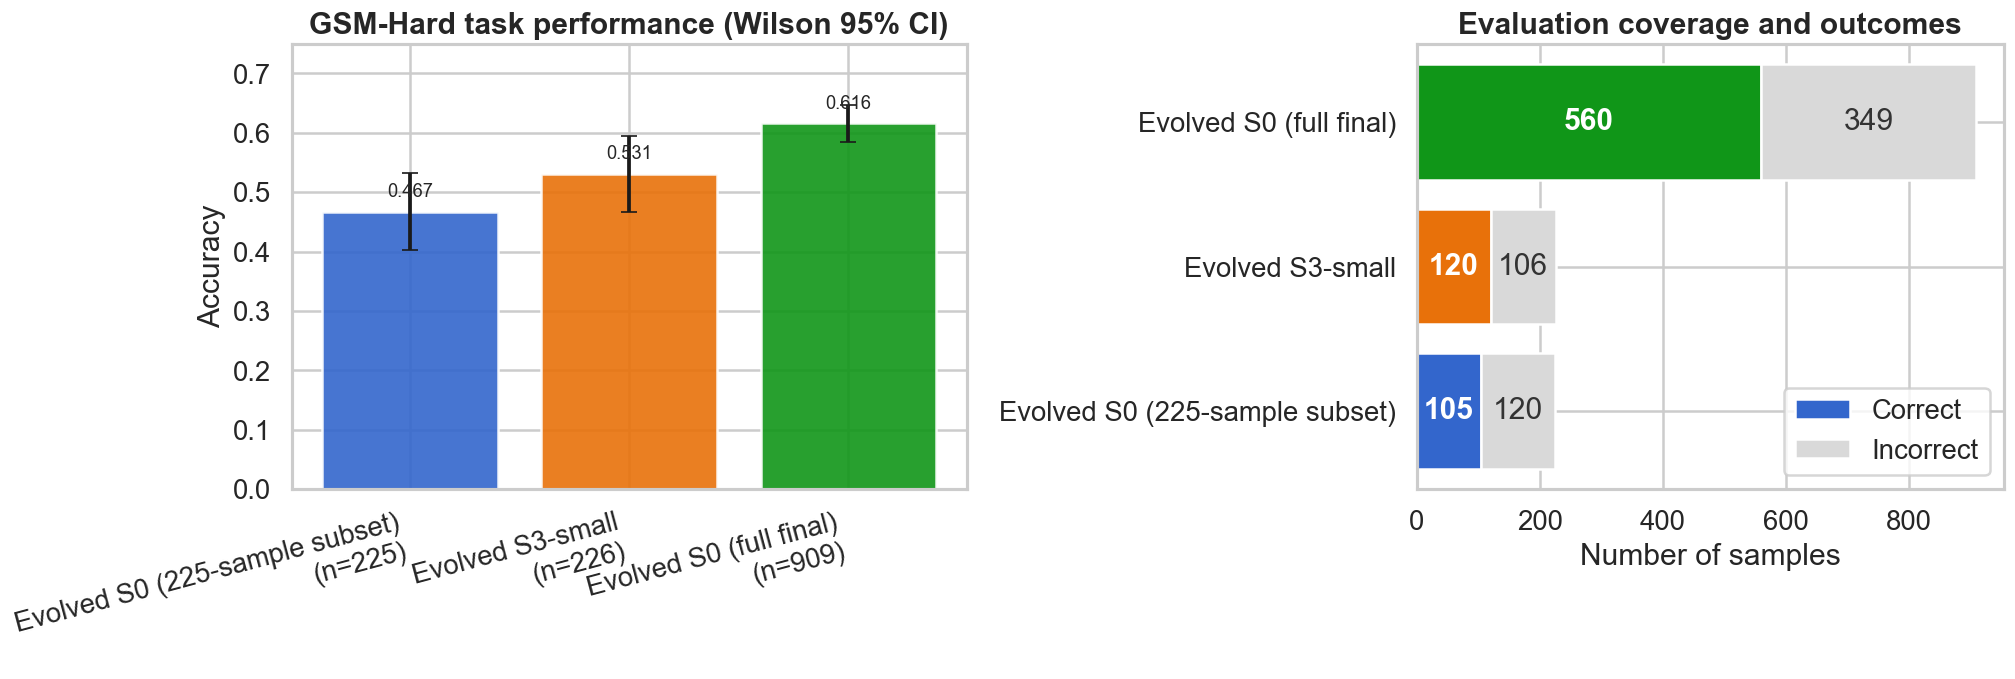

In [6]:
accuracy_rows = []
for key in EVALUATION_KEYS:
    spec = next(item for item in EXPERIMENTS if item["key"] == key)
    frame = data_by_key[key]
    n = len(frame)
    correct = int(frame["correct"].fillna(False).astype(bool).sum()) if n else 0
    low, high = wilson_interval(correct, n)
    accuracy_rows.append({
        "key": key,
        "label": spec["label"],
        "n": n,
        "correct": correct,
        "incorrect": n - correct,
        "accuracy": correct / n if n else np.nan,
        "ci_low": low,
        "ci_high": high,
        "color": spec["color"],
    })

accuracy_summary = pd.DataFrame(accuracy_rows)
display(accuracy_summary.drop(columns="color").style.format({
    "accuracy": "{:.3f}", "ci_low": "{:.3f}", "ci_high": "{:.3f}"
}))

fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={"width_ratios": [1.15, 1]})
x = np.arange(len(accuracy_summary))
acc = accuracy_summary.accuracy.to_numpy()
err = np.vstack([
    acc - accuracy_summary.ci_low.to_numpy(),
    accuracy_summary.ci_high.to_numpy() - acc,
])
axes[0].bar(x, acc, yerr=err, capsize=5, color=accuracy_summary.color, alpha=0.9)
axes[0].set_xticks(x, [f"{label}\n(n={n})" for label, n in zip(accuracy_summary.label, accuracy_summary.n)], rotation=15, ha="right")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, min(1, max(0.75, float(np.nanmax(accuracy_summary.ci_high)) + 0.08)))
axes[0].set_title("GSM-Hard task performance (Wilson 95% CI)")
for i, value in enumerate(acc):
    axes[0].text(i, value + 0.025, f"{value:.3f}", ha="center", fontsize=11)

axes[1].barh(accuracy_summary.label, accuracy_summary.correct, color=accuracy_summary.color, label="Correct")
axes[1].barh(
    accuracy_summary.label,
    accuracy_summary.incorrect,
    left=accuracy_summary.correct,
    color="#D9D9D9",
    label="Incorrect",
)
axes[1].set_xlabel("Number of samples")
axes[1].set_title("Evaluation coverage and outcomes")
axes[1].legend()
for i, row in enumerate(accuracy_summary.itertuples(index=False)):
    axes[1].text(row.correct / 2, i, str(row.correct), ha="center", va="center", color="white", fontweight="bold")
    axes[1].text(row.correct + row.incorrect / 2, i, str(row.incorrect), ha="center", va="center", color="#333333")

fig.tight_layout()
save_figure(fig, "01_run_accuracy_summary.png")
plt.show()

## 2. Efficiency và performance–cost theo từng run

Các metric efficiency chỉ dùng sample nối được result–log. `total_cost` là proxy nội bộ `tokens × model_size × 2`, dùng để mô tả biến động trong cùng setup chứ không phải chi phí billing.

,key,label,n_with_logs,accuracy,total_tokens,total_cost,agent_activations,mean_chain_length,path_count,unique_roles,correct_per_million_tokens
0,evolved_s0_subset,Evolved S0 (225-sample subset),225,0.467,11534.31,174826.28,10.28,3.43,3.00,nan,40.46
1,evolved_s3_small,Evolved S3-small,226,0.531,18810.04,246726.81,9.04,3.01,3.00,nan,28.23


Saved: 02_run_efficiency_summary.png


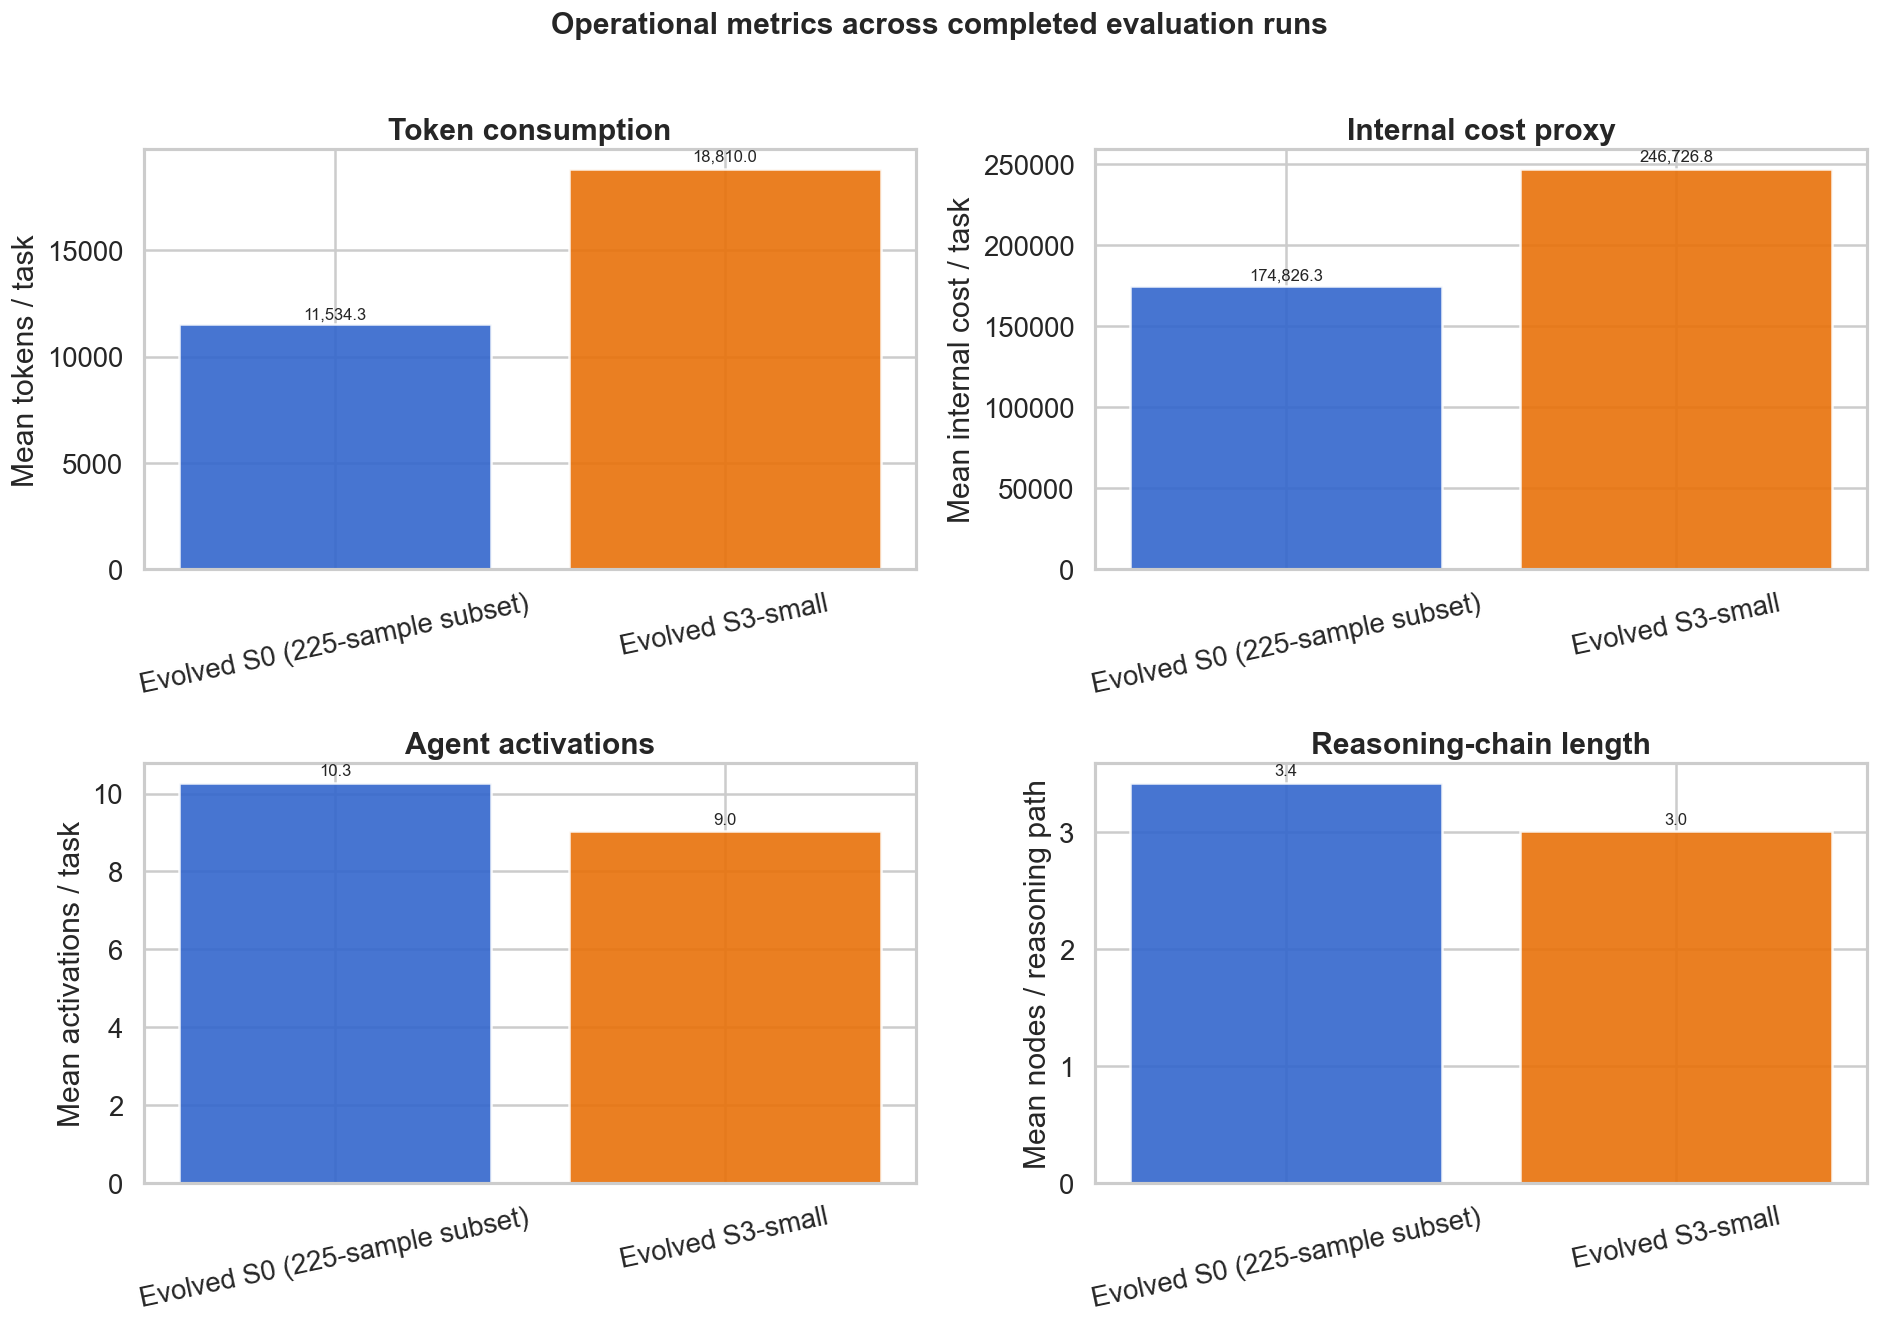

Saved: 03_performance_cost_tradeoff.png


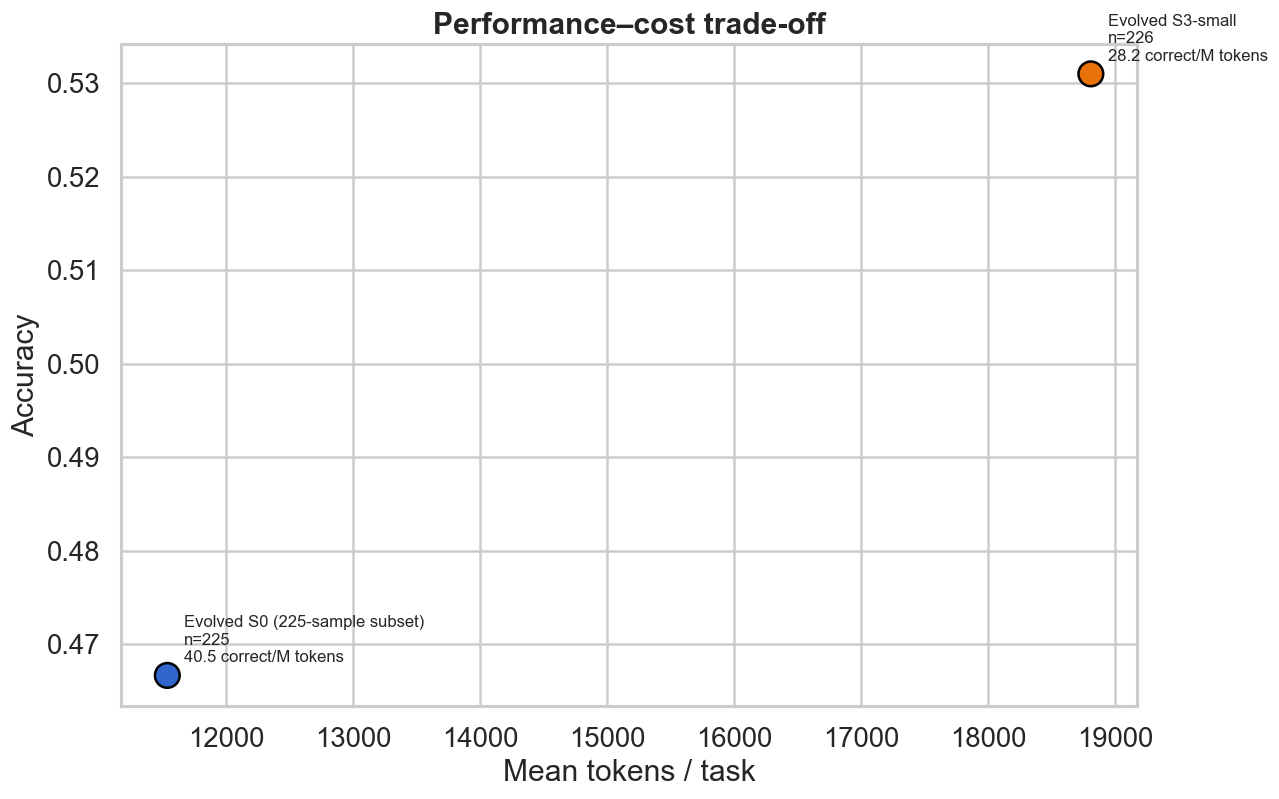

In [7]:
metric_columns = ["total_tokens", "total_cost", "agent_activations", "mean_chain_length", "path_count", "unique_roles"]
efficiency_rows = []
for key in EFFICIENCY_KEYS:
    spec = next(item for item in EXPERIMENTS if item["key"] == key)
    frame = data_by_key[key].dropna(subset=["total_tokens"]).copy()
    row = {
        "key": key,
        "label": spec["label"],
        "n_with_logs": len(frame),
        "accuracy": frame.correct.astype(float).mean(),
        "color": spec["color"],
    }
    row.update({column: frame[column].mean() for column in metric_columns})
    row["correct_per_million_tokens"] = (
        frame.correct.astype(float).sum() / max(frame.total_tokens.sum(), 1) * 1_000_000
    )
    efficiency_rows.append(row)

efficiency_summary = pd.DataFrame(efficiency_rows)
display(efficiency_summary.drop(columns="color").style.format(
    {column: "{:.2f}" for column in metric_columns + ["correct_per_million_tokens"]} | {"accuracy": "{:.3f}"}
))

panel_metrics = [
    ("total_tokens", "Mean tokens / task", "Token consumption"),
    ("total_cost", "Mean internal cost / task", "Internal cost proxy"),
    ("agent_activations", "Mean activations / task", "Agent activations"),
    ("mean_chain_length", "Mean nodes / reasoning path", "Reasoning-chain length"),
]
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for ax, (column, ylabel, title) in zip(axes.flat, panel_metrics):
    values = efficiency_summary[column].to_numpy()
    ax.bar(efficiency_summary.label, values, color=efficiency_summary.color, alpha=0.9)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=12)
    for i, value in enumerate(values):
        ax.text(i, value * 1.02, f"{value:,.1f}", ha="center", fontsize=10)
fig.suptitle("Operational metrics across completed evaluation runs", y=1.01, fontsize=18, fontweight="bold")
fig.tight_layout()
save_figure(fig, "02_run_efficiency_summary.png")
plt.show()

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(
    efficiency_summary.total_tokens,
    efficiency_summary.accuracy,
    s=220,
    c=efficiency_summary.color,
    edgecolor="black",
)
for row in efficiency_summary.itertuples(index=False):
    ax.annotate(
        f"{row.label}\nn={row.n_with_logs}\n{row.correct_per_million_tokens:.1f} correct/M tokens",
        (row.total_tokens, row.accuracy),
        xytext=(10, 8),
        textcoords="offset points",
        fontsize=10,
    )
ax.set_xlabel("Mean tokens / task")
ax.set_ylabel("Accuracy")
ax.set_title("Performance–cost trade-off")
fig.tight_layout()
save_figure(fig, "03_performance_cost_tradeoff.png")
plt.show()

## 3. Learning curves theo Figure 2/8/9

Scatter là từng training item; đường liền là local linear LOWESS dùng tricube weights, cài bằng NumPy để notebook không phụ thuộc `statsmodels`. Performance–cost ratio được chuẩn hóa thành số câu đúng trên một triệu token trung bình mỗi path.

Saved: 04_training_token_agent_performance_curves.png


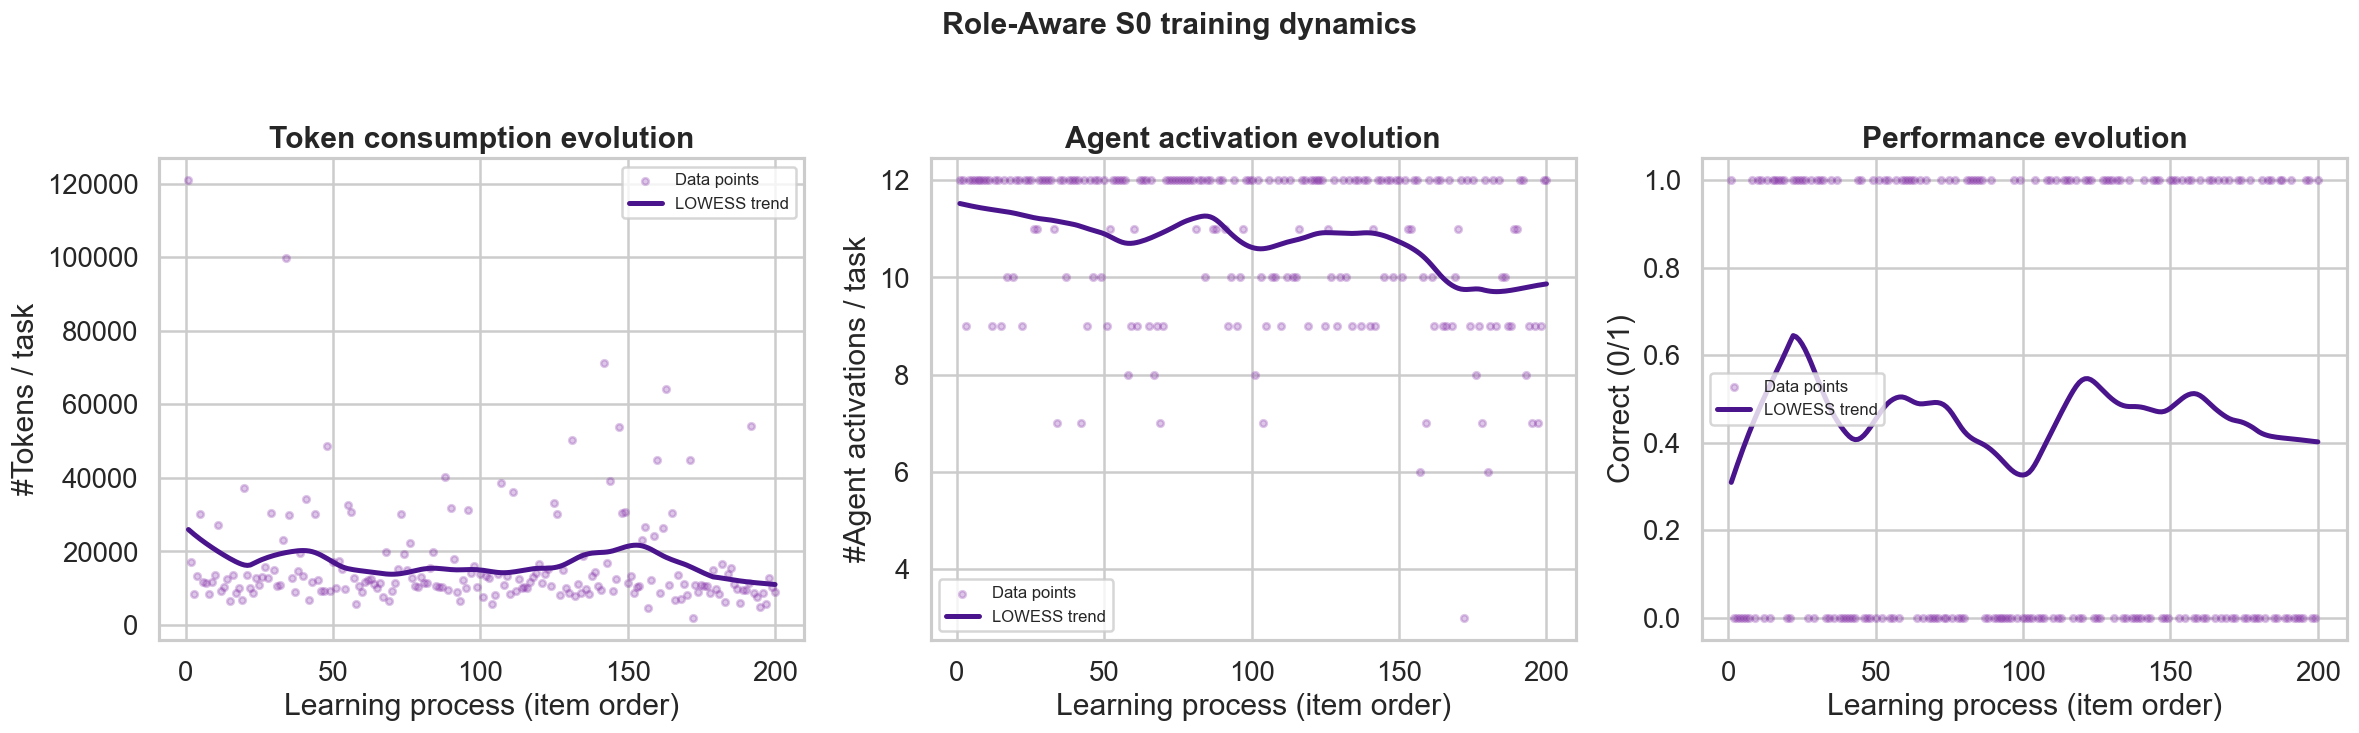

Saved: 05_training_performance_cost_curve.png


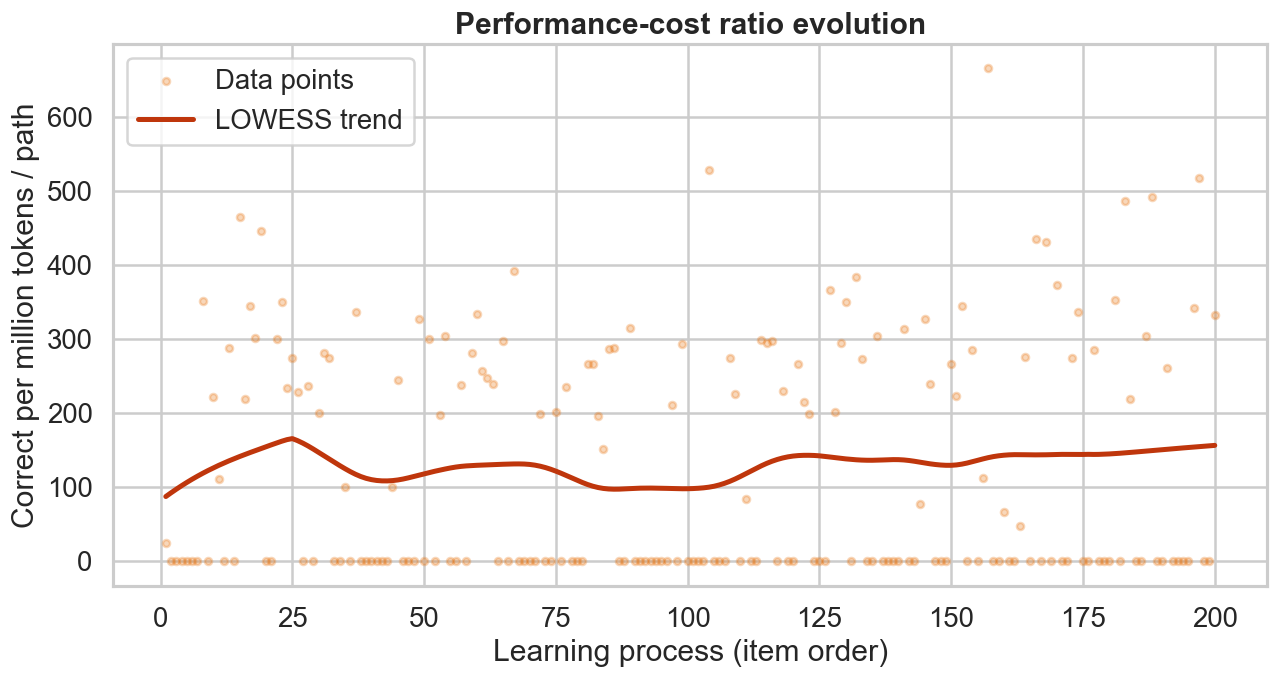

In [8]:
train = data_by_key[TRAINING_KEY].dropna(subset=["run_timestamp", "total_tokens"]).sort_values("run_timestamp").copy()
train["learning_step"] = np.arange(1, len(train) + 1)
train["correct_float"] = train.correct.astype(float)
train["token_per_path"] = train.total_tokens / train.path_count.clip(lower=1)
train["performance_cost_ratio"] = train.correct_float / train.token_per_path.clip(lower=1) * 1_000_000

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
series = [
    ("total_tokens", "#Tokens / task", "Token consumption evolution"),
    ("agent_activations", "#Agent activations / task", "Agent activation evolution"),
    ("correct_float", "Correct (0/1)", "Performance evolution"),
]
for ax, (column, ylabel, title) in zip(axes, series):
    ax.scatter(train.learning_step, train[column], s=16, alpha=0.25, color="#7B1FA2", label="Data points")
    gx, gy = lowess_numpy(train.learning_step, train[column], frac=0.22)
    ax.plot(gx, gy, color="#4A148C", linewidth=3, label="LOWESS trend")
    ax.set_xlabel("Learning process (item order)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=10)
fig.suptitle("Role-Aware S0 training dynamics", y=1.03, fontsize=18, fontweight="bold")
fig.tight_layout()
save_figure(fig, "04_training_token_agent_performance_curves.png")
plt.show()

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(train.learning_step, train.performance_cost_ratio, s=18, alpha=0.28, color="#E8710A", label="Data points")
gx, gy = lowess_numpy(train.learning_step, train.performance_cost_ratio, frac=0.25)
ax.plot(gx, gy, color="#BF360C", linewidth=3, label="LOWESS trend")
ax.set_xlabel("Learning process (item order)")
ax.set_ylabel("Correct per million tokens / path")
ax.set_title("Performance-cost ratio evolution")
ax.legend()
fig.tight_layout()
save_figure(fig, "05_training_performance_cost_curve.png")
plt.show()

## 4. Graph compaction và cyclicality: đầu–cuối training

Để mô tả topology mà không cần một run đối chứng, cell này chia training run theo timestamp và so sánh 25% task đầu với 25% task cuối. Bên trái là phân bố `E/N_active`; bên phải là số cycle trung bình trên mỗi task theo độ dài 1–4. Self-loop là cycle length 1.

Saved: 06_training_topology_early_vs_late.png


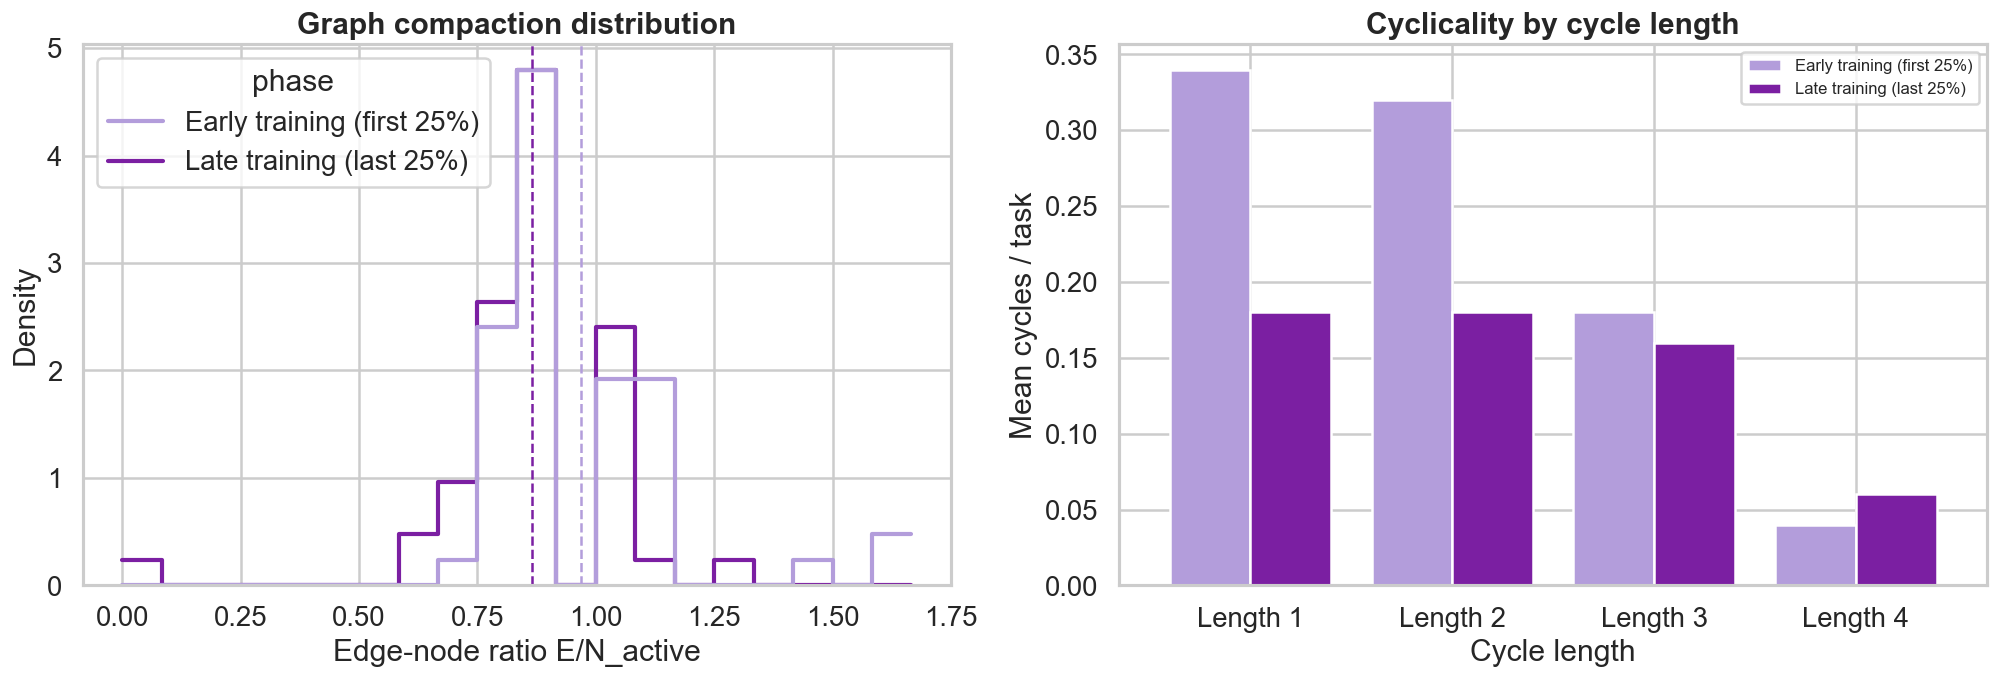

,phase,n_tasks,mean_edge_node_ratio,mean_cycle_Length 1,mean_cycle_Length 2,mean_cycle_Length 3,mean_cycle_Length 4
0,Early training (first 25%),50,0.969356,0.34,0.32,0.18,0.04
1,Late training (last 25%),50,0.864496,0.18,0.18,0.16,0.06


In [9]:
def load_topology_only(spec: dict) -> pd.DataFrame:
    group = LOGS_ROOT / spec["log_group"]
    valid_ids = set(data_by_key[spec["key"]].original_index.astype(int))
    rows = []
    for log_dir in sorted((path for path in group.iterdir() if path.is_dir()), key=lambda path: path.name):
        task_header = parse_task_header(log_dir / "meta.log", question_lookup)
        original_index = task_header["original_index"]
        if original_index is None or int(original_index) not in valid_ids:
            continue
        row = {"original_index": int(original_index), "run_timestamp": parse_folder_timestamp(log_dir.name)}
        row.update(graph_metrics(log_dir))
        rows.append(row)
    frame = pd.DataFrame(rows)
    if frame.empty:
        return frame
    return frame.sort_values("run_timestamp").drop_duplicates("original_index", keep="last").reset_index(drop=True)

training_spec = next(item for item in EXPERIMENTS if item["key"] == TRAINING_KEY)
training_topology = load_topology_only(training_spec).dropna(subset=["run_timestamp"]).sort_values("run_timestamp").reset_index(drop=True)
quartile_size = max(1, len(training_topology) // 4)
early_topology = training_topology.head(quartile_size).copy()
early_topology["phase"] = "Early training (first 25%)"
late_topology = training_topology.tail(quartile_size).copy()
late_topology["phase"] = "Late training (last 25%)"
topology = pd.concat([early_topology, late_topology], ignore_index=True)

phase_order = ["Early training (first 25%)", "Late training (last 25%)"]
palette = {phase_order[0]: "#B39DDB", phase_order[1]: "#7B1FA2"}
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.histplot(
    data=topology,
    x="edge_node_ratio",
    hue="phase",
    hue_order=phase_order,
    palette=palette,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    linewidth=2.5,
    ax=axes[0],
)
means = topology.groupby("phase", sort=False).edge_node_ratio.mean().reindex(phase_order)
for phase, value in means.items():
    axes[0].axvline(value, color=palette[phase], linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Edge-node ratio E/N_active")
axes[0].set_title("Graph compaction distribution")

cycle_columns = [f"cycles_len_{length}" for length in range(1, 5)]
cycle_means = topology.groupby("phase", sort=False)[cycle_columns].mean().reindex(phase_order)
cycle_means.columns = ["Length 1", "Length 2", "Length 3", "Length 4"]
cycle_means.T.plot(kind="bar", ax=axes[1], color=[palette[p] for p in phase_order], width=0.8)
axes[1].set_xlabel("Cycle length")
axes[1].set_ylabel("Mean cycles / task")
axes[1].set_title("Cyclicality by cycle length")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(fontsize=10)

fig.tight_layout()
save_figure(fig, "06_training_topology_early_vs_late.png")
plt.show()

topology_summary = pd.concat(
    [means.rename("mean_edge_node_ratio"), cycle_means.add_prefix("mean_cycle_")],
    axis=1,
).reset_index()
topology_summary.insert(1, "n_tasks", [len(early_topology), len(late_topology)])
display(topology_summary)

## 5. Xuất bảng báo cáo và quality checks

Cell cuối lưu các bảng CSV cạnh ảnh PNG. Hãy kiểm tra `metric_coverage`, duplicate logs, mismatch mode và `token_trace_delta` trước khi trích số vào báo cáo chính thức.

In [10]:
accuracy_summary.drop(columns="color").to_csv(REPORT_DIR / "run_accuracy.csv", index=False)
efficiency_summary.drop(columns="color").to_csv(REPORT_DIR / "run_efficiency.csv", index=False)
train.to_csv(REPORT_DIR / "training_curve_metrics.csv", index=False)
topology.to_csv(REPORT_DIR / "training_topology_early_late_tasks.csv", index=False)
topology_summary.to_csv(REPORT_DIR / "training_topology_early_late_summary.csv", index=False)

quality_rows = []
for spec in EXPERIMENTS:
    frame = data_by_key[spec["key"]]
    quality_rows.append({
        "key": spec["key"],
        "n_results": len(frame),
        "n_missing_token_metrics": int(frame["total_tokens"].isna().sum()) if "total_tokens" in frame else len(frame),
        "n_nonzero_token_trace_delta": int((frame.get("token_trace_delta", pd.Series(dtype=float)).fillna(0).abs() > 1e-6).sum()),
        "mean_token_trace_delta": float(frame.get("token_trace_delta", pd.Series(dtype=float)).dropna().mean()) if "token_trace_delta" in frame else np.nan,
    })
quality_checks = pd.DataFrame(quality_rows)
quality_checks.to_csv(REPORT_DIR / "quality_checks.csv", index=False)
display(quality_checks)

print("Hoàn tất. Files đã tạo:")
for path in sorted(REPORT_DIR.iterdir()):
    print(f"- {path.name}")

,key,n_results,n_missing_token_metrics,n_nonzero_token_trace_delta,mean_token_trace_delta
0,evolved_s0_subset,225,0,0,0.0
1,evolved_s3_small,226,0,0,0.0
2,evolved_s0_full,909,909,0,NaN
3,training_s0,200,0,0,0.0


Hoàn tất. Files đã tạo:
- 01_run_accuracy_summary.png
- 02_run_efficiency_summary.png
- 03_performance_cost_tradeoff.png
- 04_training_token_agent_performance_curves.png
- 05_training_performance_cost_curve.png
- 06_training_topology_early_vs_late.png
- coverage_diagnostics.csv
- quality_checks.csv
- run_accuracy.csv
- run_efficiency.csv
- run_mapping_diagnostics.csv
- training_curve_metrics.csv
- training_topology_early_late_summary.csv
- training_topology_early_late_tasks.csv
